In [1]:
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

WESAD_ROOT = Path(r"C:\Users\mbnv6\Project\Dataset\WESAD")
TARGET_SUBJECTS = [
    "S2", "S3", "S4", "S5", "S6",
    "S7", "S8", "S9", "S10", "S11",
    "S13", "S14", "S15", "S16", "S17",
]

STATE_NAMES = {1: "Baseline", 2: "Stress", 3: "Amusement"}
STATE_COLORS = {1: "#2ecc71", 2: "#e74c3c", 3: "#3498db"}


def downsample_wrist(wrist):
    bvp = wrist["BVP"].reshape(-1)
    acc = wrist["ACC"]
    eda = wrist["EDA"].reshape(-1)
    temp = wrist["TEMP"].reshape(-1)

    # Original sampling rates: BVP=64Hz, ACC=32Hz, EDA=4Hz, TEMP=4Hz
    return bvp[::64], acc[::32], eda[::4], temp[::4]


def downsample_labels_1hz(labels):
    # Labels are sampled at 700Hz in WESAD
    return labels[::700].reshape(-1)


def add_stimulus_background(ax, labels_1hz, time_min):
    if len(labels_1hz) == 0:
        return

    step = (time_min[1] - time_min[0]) if len(time_min) > 1 else 1.0 / 60.0
    start = 0
    for i in range(1, len(labels_1hz) + 1):
        if i == len(labels_1hz) or labels_1hz[i] != labels_1hz[start]:
            label = int(labels_1hz[start])
            if label in STATE_COLORS:
                ax.axvspan(
                    time_min[start],
                    time_min[i - 1] + step,
                    color=STATE_COLORS[label],
                    alpha=0.12,
                    label=STATE_NAMES[label],
                )
            start = i


def downsample_chest(chest):
    acc = chest["ACC"]
    ecg = chest["ECG"].reshape(-1)
    emg = chest["EMG"].reshape(-1)
    temp = chest["Temp"].reshape(-1)

    # Original sampling rates: ECG=700Hz, EMG=700Hz, ACC=32Hz, Temp=4Hz
    return acc[::32], ecg[::700], emg[::700], temp[::4]


def plot_subject_wrist(subject_id):
    pkl_path = WESAD_ROOT / subject_id / f"{subject_id}.pkl"
    if not pkl_path.exists():
        print(f"Missing subject file: {pkl_path}")
        return

    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    wrist = data["signal"]["wrist"]
    labels = data["label"].reshape(-1)

    bvp_ds, acc_ds, eda_ds, temp_ds = downsample_wrist(wrist)
    labels_1hz = downsample_labels_1hz(labels)

    def trim_to_labels(sensor):
        n = min(len(sensor), len(labels_1hz))
        return sensor[:n], labels_1hz[:n]

    bvp_ds, labels_bvp = trim_to_labels(bvp_ds)
    acc_ds, labels_acc = trim_to_labels(acc_ds)
    eda_ds, labels_eda = trim_to_labels(eda_ds)
    temp_ds, labels_temp = trim_to_labels(temp_ds)

    time_bvp_min = np.arange(len(bvp_ds)) / 60.0
    time_acc_min = np.arange(len(acc_ds)) / 60.0
    time_eda_min = np.arange(len(eda_ds)) / 60.0
    time_temp_min = np.arange(len(temp_ds)) / 60.0

    fig, axes = plt.subplots(4, 1, figsize=(20, 12))
    fig.suptitle(
        f"{subject_id} Wrist Sensors (1Hz) with Stimulus Timeline",
        fontsize=14,
        fontweight="bold",
    )

    add_stimulus_background(axes[0], labels_bvp, time_bvp_min)
    axes[0].plot(time_bvp_min, bvp_ds, linewidth=0.5, color="darkred", alpha=0.8)
    axes[0].set_title("BVP (Blood Volume Pulse)")
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(True, alpha=0.3)
    handles, labels_legend = axes[0].get_legend_handles_labels()
    if handles:
        by_label = dict(zip(labels_legend, handles))
        axes[0].legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=9, ncol=3)

    add_stimulus_background(axes[1], labels_acc, time_acc_min)
    axes[1].plot(time_acc_min, acc_ds[:, 0], label="X-axis", linewidth=0.5, alpha=0.7)
    axes[1].plot(time_acc_min, acc_ds[:, 1], label="Y-axis", linewidth=0.5, alpha=0.7)
    axes[1].plot(time_acc_min, acc_ds[:, 2], label="Z-axis", linewidth=0.5, alpha=0.7)
    axes[1].set_title("ACC (Accelerometer 3-axis)")
    axes[1].set_ylabel("Acceleration")
    axes[1].legend(loc="upper right", fontsize=9, ncol=3)
    axes[1].grid(True, alpha=0.3)

    add_stimulus_background(axes[2], labels_eda, time_eda_min)
    axes[2].plot(time_eda_min, eda_ds, linewidth=1, color="darkgreen", alpha=0.8)
    axes[2].set_title("EDA (Electrodermal Activity)")
    axes[2].set_ylabel("uS")
    axes[2].grid(True, alpha=0.3)

    add_stimulus_background(axes[3], labels_temp, time_temp_min)
    axes[3].plot(time_temp_min, temp_ds, linewidth=1, color="darkorange", alpha=0.8)
    axes[3].set_title("TEMP (Skin Temperature)")
    axes[3].set_ylabel("C")
    axes[3].set_xlabel("Time (minutes)")
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("Color legend: Baseline=green, Stress=red, Amusement=blue")


def plot_subject_chest(subject_id):
    pkl_path = WESAD_ROOT / subject_id / f"{subject_id}.pkl"
    if not pkl_path.exists():
        print(f"Missing subject file: {pkl_path}")
        return

    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    chest = data["signal"]["chest"]
    labels = data["label"].reshape(-1)

    acc_ds, ecg_ds, emg_ds, temp_ds = downsample_chest(chest)
    labels_1hz = downsample_labels_1hz(labels)

    def trim_to_labels(sensor):
        n = min(len(sensor), len(labels_1hz))
        return sensor[:n], labels_1hz[:n]

    acc_ds, labels_acc = trim_to_labels(acc_ds)
    ecg_ds, labels_ecg = trim_to_labels(ecg_ds)
    emg_ds, labels_emg = trim_to_labels(emg_ds)
    temp_ds, labels_temp = trim_to_labels(temp_ds)

    time_acc_min = np.arange(len(acc_ds)) / 60.0
    time_ecg_min = np.arange(len(ecg_ds)) / 60.0
    time_emg_min = np.arange(len(emg_ds)) / 60.0
    time_temp_min = np.arange(len(temp_ds)) / 60.0

    fig, axes = plt.subplots(4, 1, figsize=(20, 12))
    fig.suptitle(
        f"{subject_id} Chest Sensors (1Hz) with Stimulus Timeline",
        fontsize=14,
        fontweight="bold",
    )

    add_stimulus_background(axes[0], labels_acc, time_acc_min)
    axes[0].plot(time_acc_min, acc_ds[:, 0], label="X-axis", linewidth=0.5, alpha=0.7)
    axes[0].plot(time_acc_min, acc_ds[:, 1], label="Y-axis", linewidth=0.5, alpha=0.7)
    axes[0].plot(time_acc_min, acc_ds[:, 2], label="Z-axis", linewidth=0.5, alpha=0.7)
    axes[0].set_title("ACC (Accelerometer 3-axis)")
    axes[0].set_ylabel("Acceleration")
    axes[0].legend(loc="upper right", fontsize=9, ncol=3)
    axes[0].grid(True, alpha=0.3)
    handles, labels_legend = axes[0].get_legend_handles_labels()
    if handles:
        by_label = dict(zip(labels_legend, handles))
        axes[0].legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=9, ncol=3)

    add_stimulus_background(axes[1], labels_ecg, time_ecg_min)
    axes[1].plot(time_ecg_min, ecg_ds, linewidth=0.5, color="purple", alpha=0.8)
    axes[1].set_title("ECG (Electrocardiogram)")
    axes[1].set_ylabel("Amplitude")
    axes[1].grid(True, alpha=0.3)

    add_stimulus_background(axes[2], labels_emg, time_emg_min)
    axes[2].plot(time_emg_min, emg_ds, linewidth=0.5, color="brown", alpha=0.8)
    axes[2].set_title("EMG (Electromyography)")
    axes[2].set_ylabel("Amplitude")
    axes[2].grid(True, alpha=0.3)

    add_stimulus_background(axes[3], labels_temp, time_temp_min)
    axes[3].plot(time_temp_min, temp_ds, linewidth=1, color="darkorange", alpha=0.8)
    axes[3].set_title("TEMP (Skin Temperature)")
    axes[3].set_ylabel("C")
    axes[3].set_xlabel("Time (minutes)")
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("Color legend: Baseline=green, Stress=red, Amusement=blue")

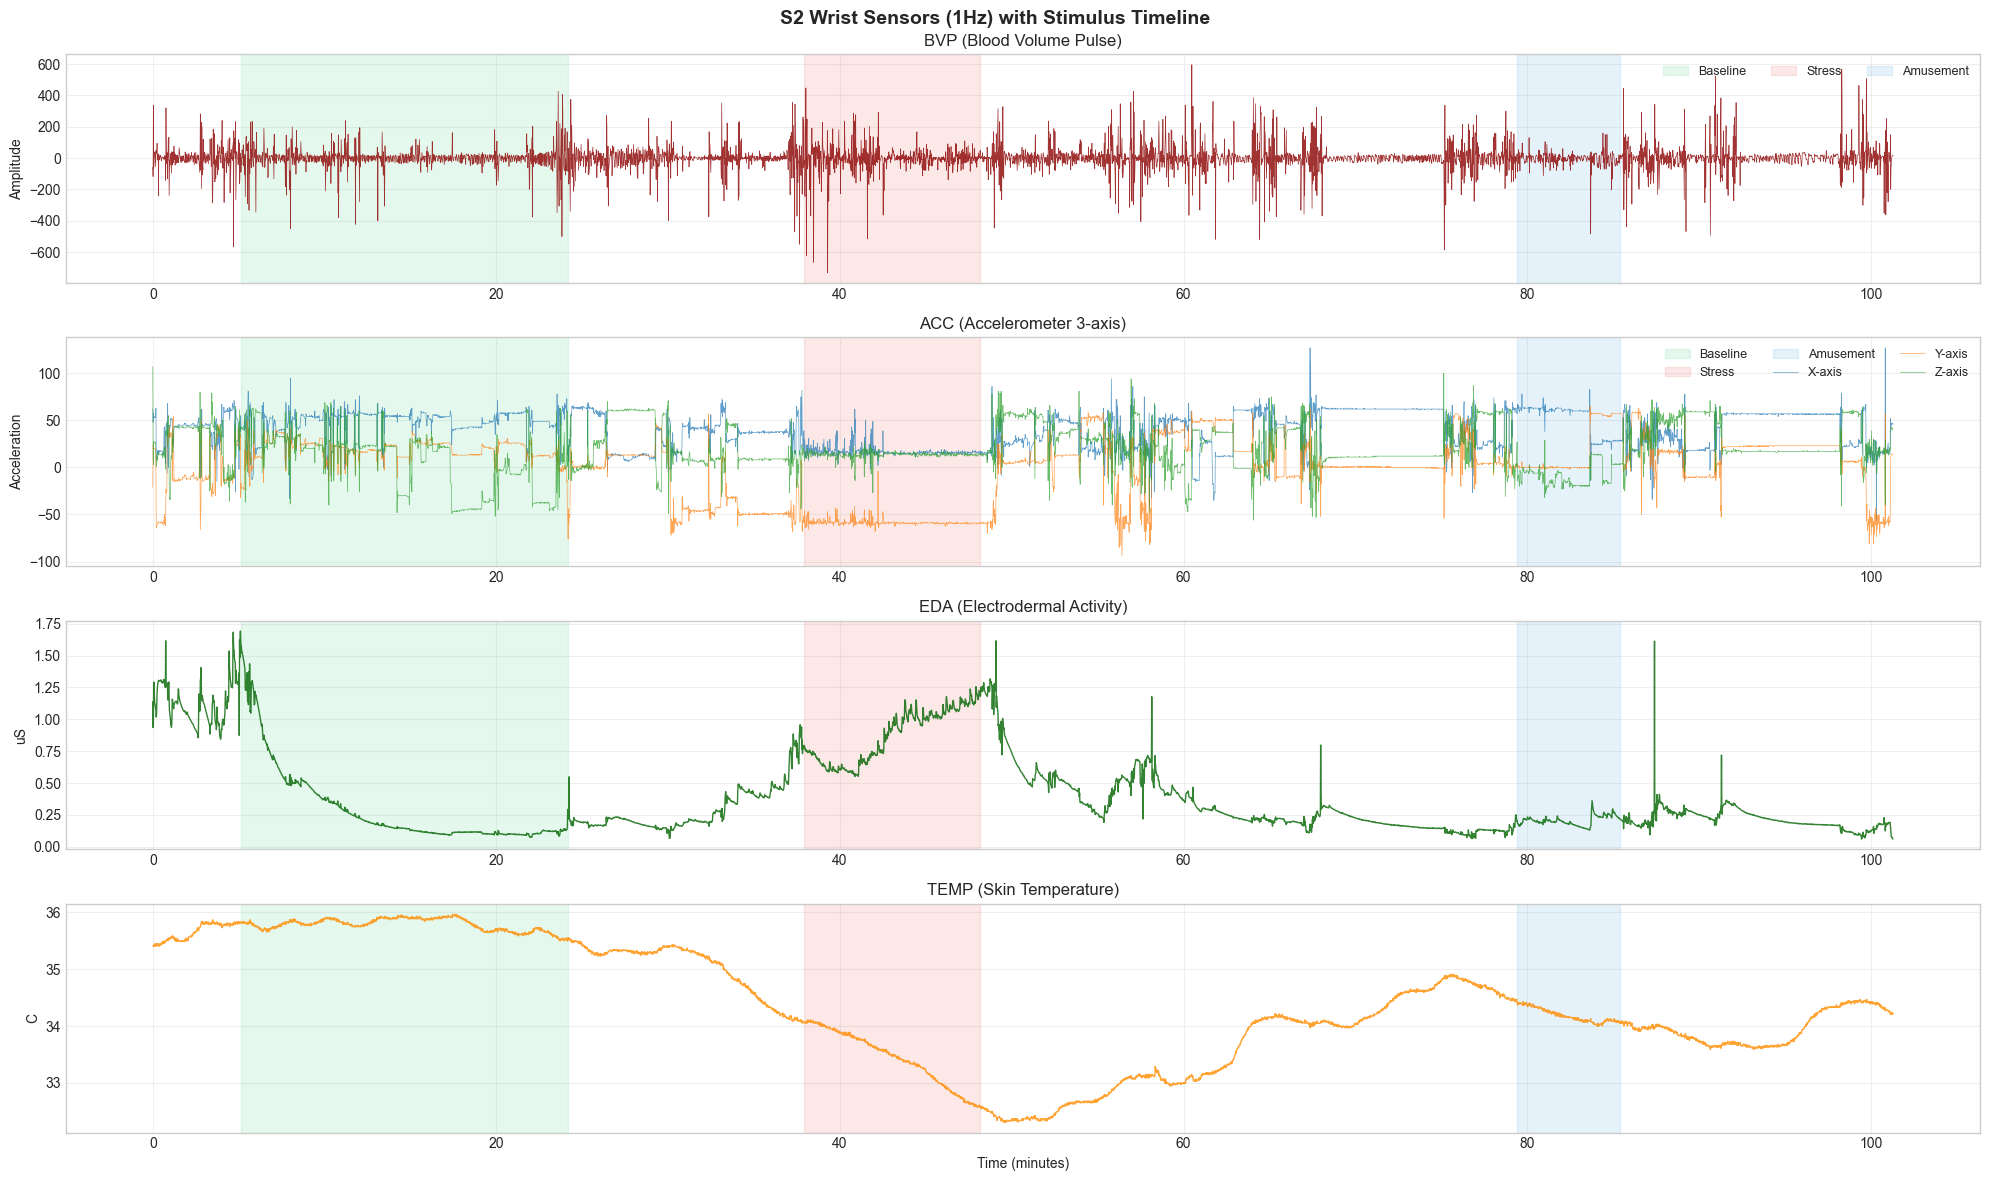

Color legend: Baseline=green, Stress=red, Amusement=blue


In [2]:
plot_subject_wrist("S2")

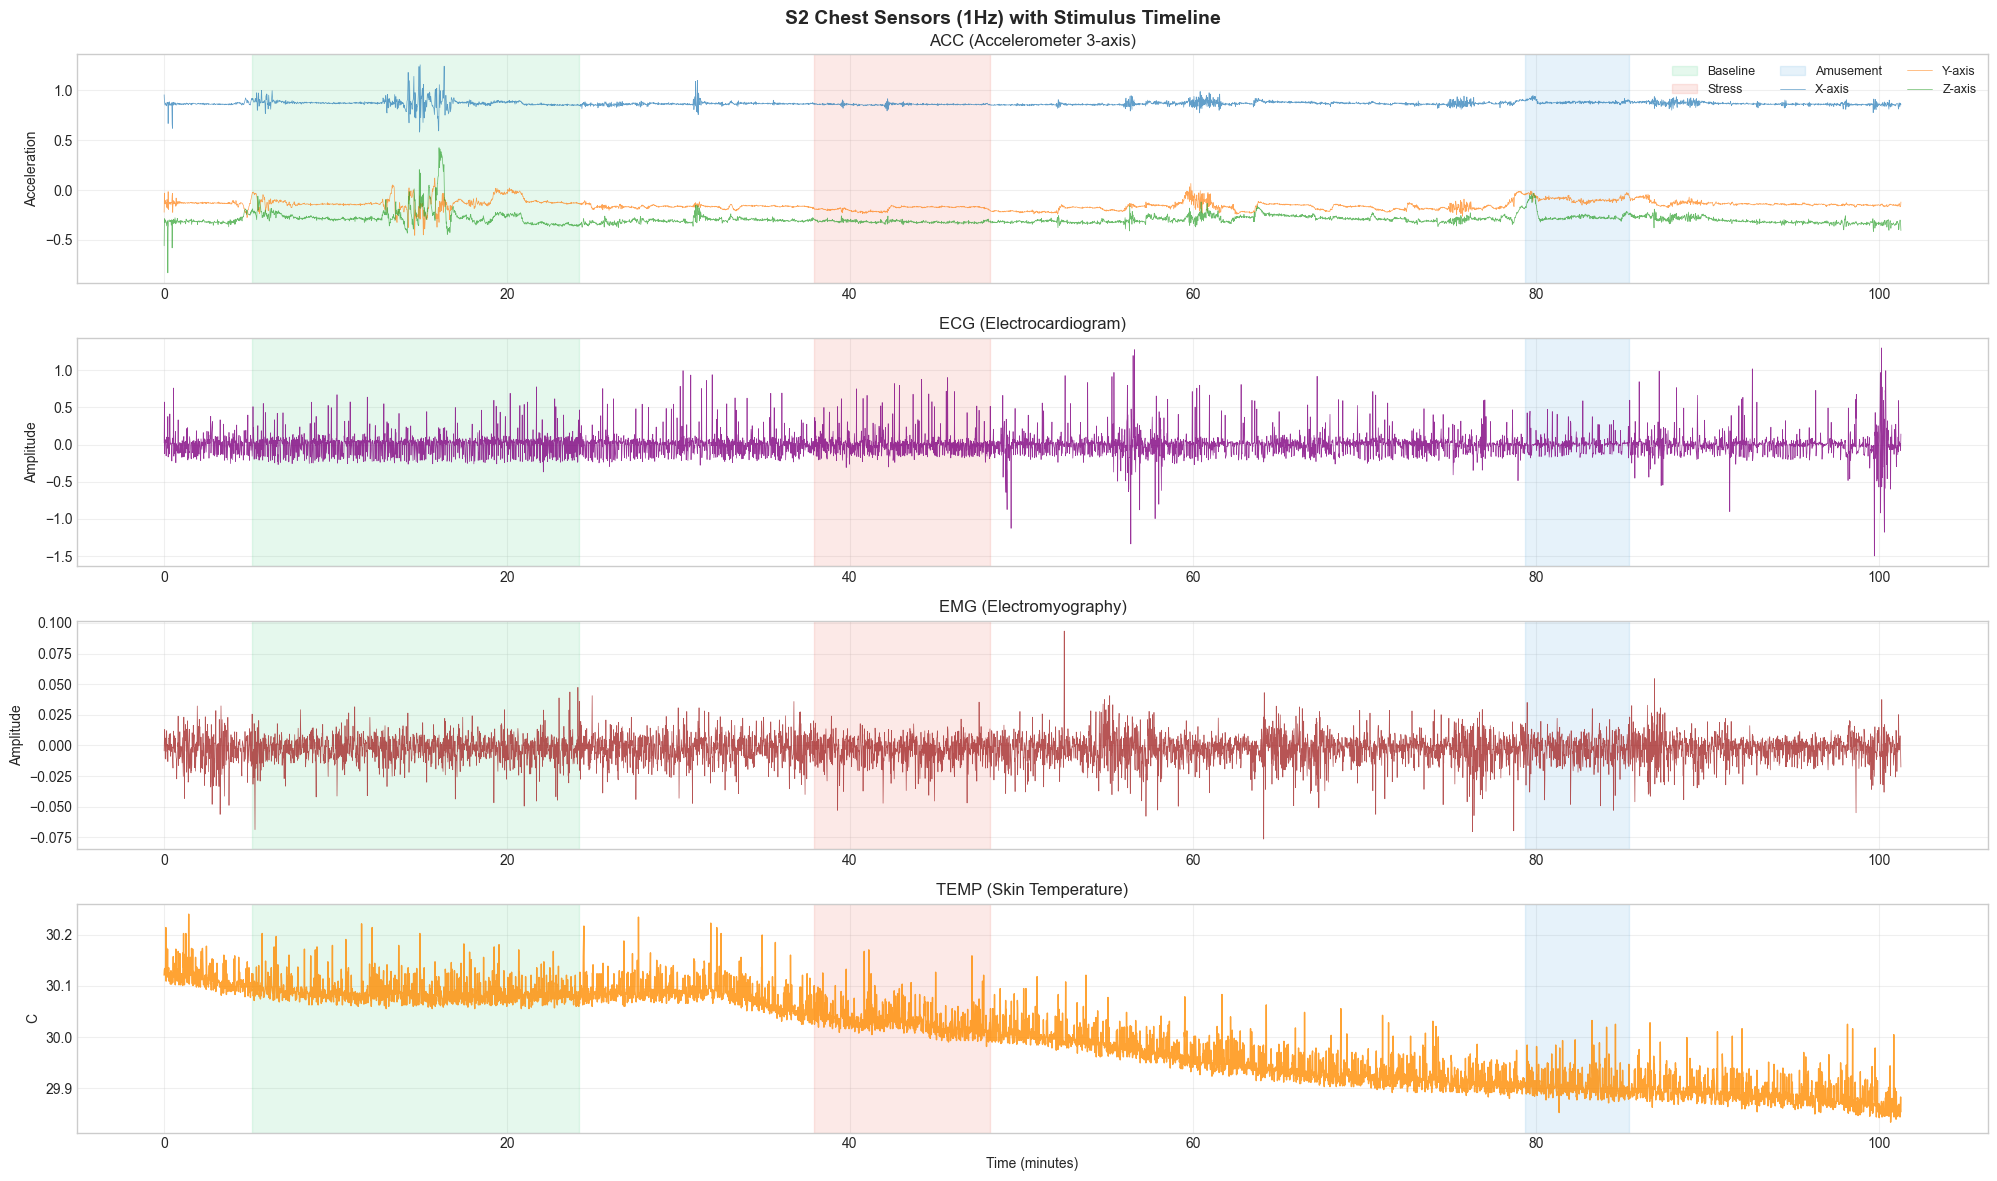

Color legend: Baseline=green, Stress=red, Amusement=blue


In [3]:
plot_subject_chest("S2")

S2 SUBJECT ANALYSIS: Baseline vs Stress vs Amusement

BASELINE:
  BVP:      Mean=-1.1059, Std=66.8785
  ACC-X:    Mean=48.8042
  ACC-Y:    Mean=18.3811
  ACC-Z:    Mean=6.6084
  ACC-Mag:  Mean=63.3429, Std=2.8810
  EDA:      Mean=0.2980, Std=0.3100
  TEMP:     Mean=35.7861, Std=0.1085
  EMG:      Mean=-0.0025, Std=0.0105

STRESS:
  BVP:      Mean=-2.8914, Std=85.8146
  ACC-X:    Mean=16.9951
  ACC-Y:    Mean=-58.5593
  ACC-Z:    Mean=13.6244
  ACC-Mag:  Mean=62.8428, Std=3.1883
  EDA:      Mean=0.8703, Std=0.2044
  TEMP:     Mean=33.4415, Std=0.4628
  EMG:      Mean=-0.0034, Std=0.0106

AMUSEMENT:
  BVP:      Mean=-2.9812, Std=45.1636
  ACC-X:    Mean=51.1989
  ACC-Y:    Mean=16.5552
  ACC-Z:    Mean=-8.1602
  ACC-Mag:  Mean=63.3584, Std=2.3075
  EDA:      Mean=0.2062, Std=0.0382
  TEMP:     Mean=34.1906, Std=0.1200
  EMG:      Mean=-0.0030, Std=0.0113

CHANGE FROM BASELINE (%)

STRESS:
  BVP:      +161.46%
  ACC-Mag:  -0.79%
  EDA:      +192.02%
  TEMP:     -6.55%
  EMG:      +38.97%


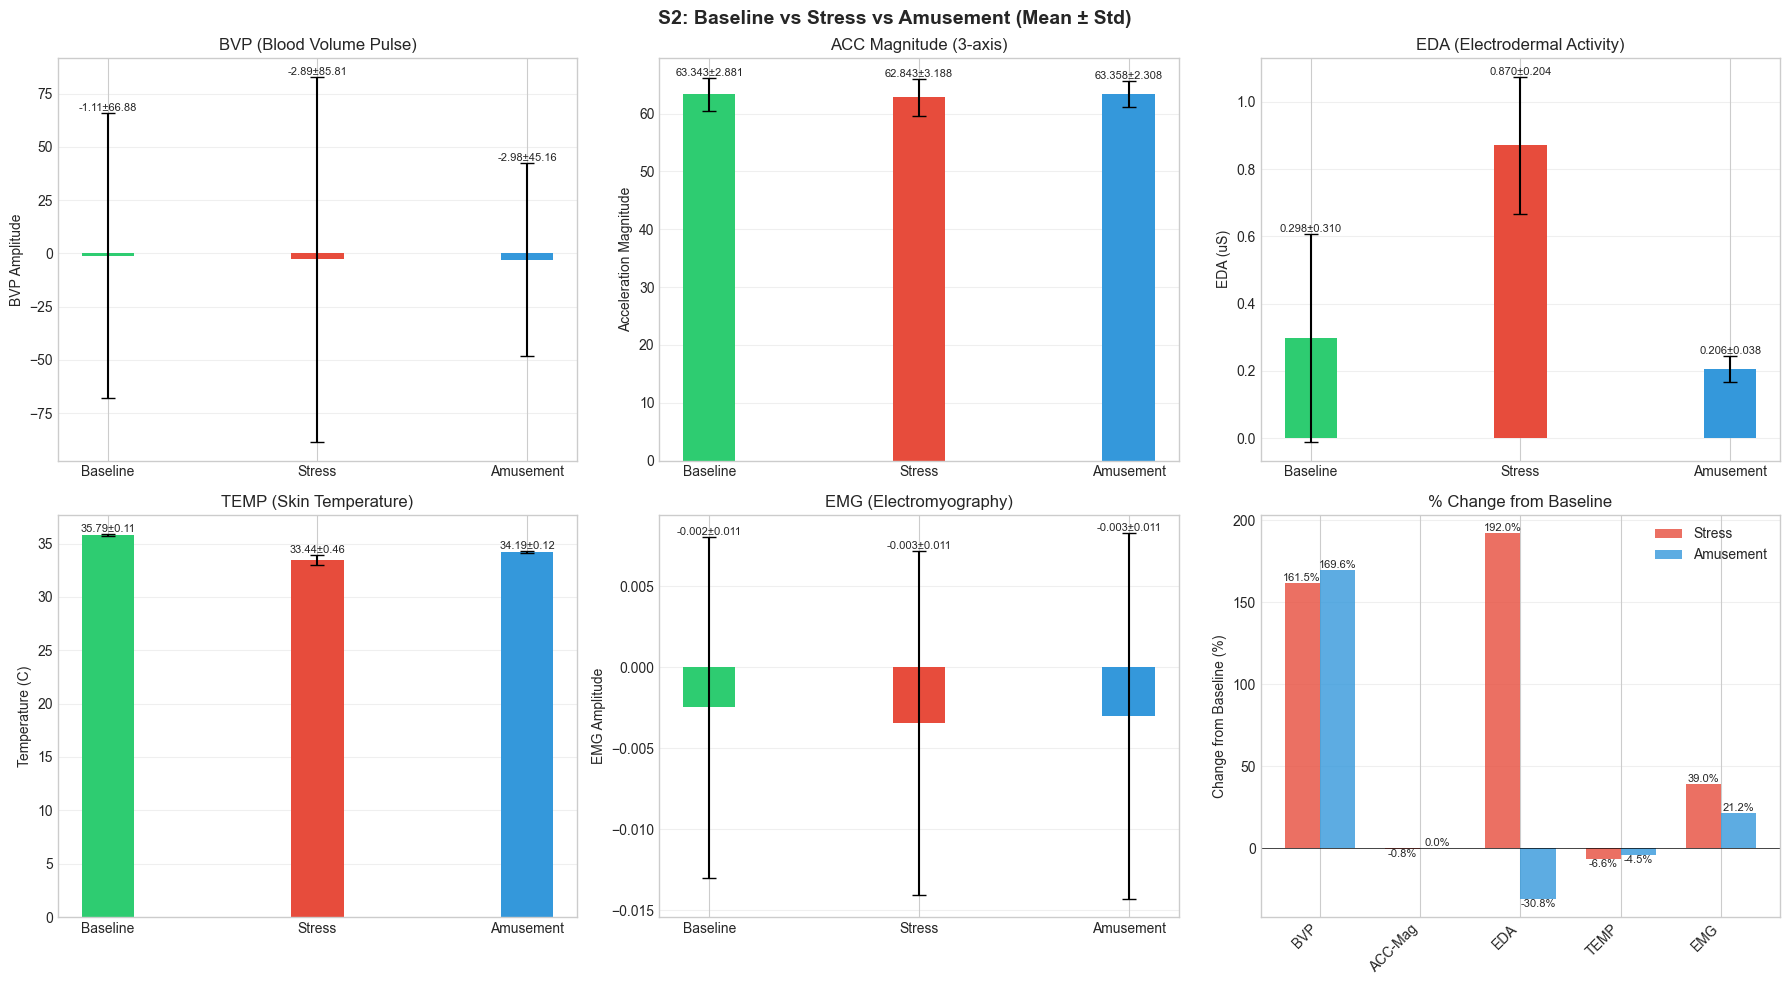

In [21]:
# S2 Analysis: Baseline vs Stress vs Amusement
import pandas as pd

pkl_path = WESAD_ROOT / "S2" / "S2.pkl"
with open(pkl_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

wrist = data["signal"]["wrist"]
chest = data["signal"]["chest"]
labels = data["label"].reshape(-1)

# Downsample
bvp_ds, acc_ds, eda_ds, temp_ds = downsample_wrist(wrist)
acc_chest_ds, ecg_ds, emg_ds, temp_chest_ds = downsample_chest(chest)
labels_1hz = downsample_labels_1hz(labels)

# Trim all to same length
min_len = len(labels_1hz)
bvp_ds = bvp_ds[:min_len]
acc_ds = acc_ds[:min_len]
eda_ds = eda_ds[:min_len]
temp_ds = temp_ds[:min_len]
emg_ds = emg_ds[:min_len]

# Calculate statistics per state
states = [1, 2, 3]
state_names = ["Baseline", "Stress", "Amusement"]
colors = ["#2ecc71", "#e74c3c", "#3498db"]

results = {}
for state, state_name in zip(states, state_names):
    mask = labels_1hz == state
    if np.sum(mask) > 0:
        acc_mag = np.sqrt(np.sum(acc_ds[mask]**2, axis=1))
        results[state_name] = {
            "BVP_mean": np.mean(bvp_ds[mask]),
            "BVP_std": np.std(bvp_ds[mask]),
            "ACC_X_mean": np.mean(acc_ds[mask, 0]),
            "ACC_Y_mean": np.mean(acc_ds[mask, 1]),
            "ACC_Z_mean": np.mean(acc_ds[mask, 2]),
            "ACC_mag_mean": np.mean(acc_mag),
            "ACC_mag_std": np.std(acc_mag),
            "EDA_mean": np.mean(eda_ds[mask]),
            "EDA_std": np.std(eda_ds[mask]),
            "TEMP_mean": np.mean(temp_ds[mask]),
            "TEMP_std": np.std(temp_ds[mask]),
            "EMG_mean": np.mean(emg_ds[mask]),
            "EMG_std": np.std(emg_ds[mask]),
        }

# Print numerical results
print("=" * 80)
print("S2 SUBJECT ANALYSIS: Baseline vs Stress vs Amusement")
print("=" * 80)
for state_name in state_names:
    if state_name in results:
        print(f"\n{state_name.upper()}:")
        print(f"  BVP:      Mean={results[state_name]['BVP_mean']:.4f}, Std={results[state_name]['BVP_std']:.4f}")
        print(f"  ACC-X:    Mean={results[state_name]['ACC_X_mean']:.4f}")
        print(f"  ACC-Y:    Mean={results[state_name]['ACC_Y_mean']:.4f}")
        print(f"  ACC-Z:    Mean={results[state_name]['ACC_Z_mean']:.4f}")
        print(f"  ACC-Mag:  Mean={results[state_name]['ACC_mag_mean']:.4f}, Std={results[state_name]['ACC_mag_std']:.4f}")
        print(f"  EDA:      Mean={results[state_name]['EDA_mean']:.4f}, Std={results[state_name]['EDA_std']:.4f}")
        print(f"  TEMP:     Mean={results[state_name]['TEMP_mean']:.4f}, Std={results[state_name]['TEMP_std']:.4f}")
        print(f"  EMG:      Mean={results[state_name]['EMG_mean']:.4f}, Std={results[state_name]['EMG_std']:.4f}")

# Calculate change ratios (Baseline as reference)
baseline_vals = results.get("Baseline", {})
print("\n" + "=" * 80)
print("CHANGE FROM BASELINE (%)")
print("=" * 80)

for state_name in ["Stress", "Amusement"]:
    if state_name in results and baseline_vals:
        print(f"\n{state_name.upper()}:")
        bvp_change = ((results[state_name]["BVP_mean"] - baseline_vals["BVP_mean"]) / baseline_vals["BVP_mean"] * 100) if baseline_vals["BVP_mean"] != 0 else 0
        eda_change = ((results[state_name]["EDA_mean"] - baseline_vals["EDA_mean"]) / baseline_vals["EDA_mean"] * 100) if baseline_vals["EDA_mean"] != 0 else 0
        temp_change = ((results[state_name]["TEMP_mean"] - baseline_vals["TEMP_mean"]) / baseline_vals["TEMP_mean"] * 100) if baseline_vals["TEMP_mean"] != 0 else 0
        emg_change = ((results[state_name]["EMG_mean"] - baseline_vals["EMG_mean"]) / baseline_vals["EMG_mean"] * 100) if baseline_vals["EMG_mean"] != 0 else 0
        acc_mag_change = ((results[state_name]["ACC_mag_mean"] - baseline_vals["ACC_mag_mean"]) / baseline_vals["ACC_mag_mean"] * 100) if baseline_vals["ACC_mag_mean"] != 0 else 0
        
        print(f"  BVP:      {bvp_change:+.2f}%")
        print(f"  ACC-Mag:  {acc_mag_change:+.2f}%")
        print(f"  EDA:      {eda_change:+.2f}%")
        print(f"  TEMP:     {temp_change:+.2f}%")
        print(f"  EMG:      {emg_change:+.2f}%")

# Create bar graphs
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("S2: Baseline vs Stress vs Amusement (Mean ± Std)", fontsize=14, fontweight="bold")

# Prepare data for plotting
sensors = ["BVP", "ACC-Mag", "EDA", "TEMP", "EMG"]
baseline_data = [
    results["Baseline"]["BVP_mean"],
    results["Baseline"]["ACC_mag_mean"],
    results["Baseline"]["EDA_mean"],
    results["Baseline"]["TEMP_mean"],
    results["Baseline"]["EMG_mean"],
]
baseline_std = [
    results["Baseline"]["BVP_std"],
    results["Baseline"]["ACC_mag_std"],
    results["Baseline"]["EDA_std"],
    results["Baseline"]["TEMP_std"],
    results["Baseline"]["EMG_std"],
]
stress_data = [
    results["Stress"]["BVP_mean"],
    results["Stress"]["ACC_mag_mean"],
    results["Stress"]["EDA_mean"],
    results["Stress"]["TEMP_mean"],
    results["Stress"]["EMG_mean"],
]
stress_std = [
    results["Stress"]["BVP_std"],
    results["Stress"]["ACC_mag_std"],
    results["Stress"]["EDA_std"],
    results["Stress"]["TEMP_std"],
    results["Stress"]["EMG_std"],
]
amusement_data = [
    results["Amusement"]["BVP_mean"],
    results["Amusement"]["ACC_mag_mean"],
    results["Amusement"]["EDA_mean"],
    results["Amusement"]["TEMP_mean"],
    results["Amusement"]["EMG_mean"],
]
amusement_std = [
    results["Amusement"]["BVP_std"],
    results["Amusement"]["ACC_mag_std"],
    results["Amusement"]["EDA_std"],
    results["Amusement"]["TEMP_std"],
    results["Amusement"]["EMG_std"],
]

# Plot 1: BVP
x = np.arange(3)
width = 0.25
ax = axes[0, 0]
values = [baseline_data[0], stress_data[0], amusement_data[0]]
stds = [baseline_std[0], stress_std[0], amusement_std[0]]
bars = ax.bar(x, values, width, yerr=stds, color=colors, capsize=5, error_kw={'linewidth': 1.5})
ax.set_ylabel("BVP Amplitude")
ax.set_title("BVP (Blood Volume Pulse)")
ax.set_xticks(x)
ax.set_xticklabels(["Baseline", "Stress", "Amusement"])
ax.grid(True, alpha=0.3, axis='y')
for bar, val, std in zip(bars, values, stds):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + std,
            f'{val:.2f}±{std:.2f}', ha='center', va='bottom', fontsize=8)

# Plot 2: ACC Magnitude
ax = axes[0, 1]
values = [baseline_data[1], stress_data[1], amusement_data[1]]
stds = [baseline_std[1], stress_std[1], amusement_std[1]]
bars = ax.bar(x, values, width, yerr=stds, color=colors, capsize=5, error_kw={'linewidth': 1.5})
ax.set_ylabel("Acceleration Magnitude")
ax.set_title("ACC Magnitude (3-axis)")
ax.set_xticks(x)
ax.set_xticklabels(["Baseline", "Stress", "Amusement"])
ax.grid(True, alpha=0.3, axis='y')
for bar, val, std in zip(bars, values, stds):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + std,
            f'{val:.3f}±{std:.3f}', ha='center', va='bottom', fontsize=8)

# Plot 3: EDA
ax = axes[0, 2]
values = [baseline_data[2], stress_data[2], amusement_data[2]]
stds = [baseline_std[2], stress_std[2], amusement_std[2]]
bars = ax.bar(x, values, width, yerr=stds, color=colors, capsize=5, error_kw={'linewidth': 1.5})
ax.set_ylabel("EDA (uS)")
ax.set_title("EDA (Electrodermal Activity)")
ax.set_xticks(x)
ax.set_xticklabels(["Baseline", "Stress", "Amusement"])
ax.grid(True, alpha=0.3, axis='y')
for bar, val, std in zip(bars, values, stds):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + std,
            f'{val:.3f}±{std:.3f}', ha='center', va='bottom', fontsize=8)

# Plot 4: TEMP
ax = axes[1, 0]
values = [baseline_data[3], stress_data[3], amusement_data[3]]
stds = [baseline_std[3], stress_std[3], amusement_std[3]]
bars = ax.bar(x, values, width, yerr=stds, color=colors, capsize=5, error_kw={'linewidth': 1.5})
ax.set_ylabel("Temperature (C)")
ax.set_title("TEMP (Skin Temperature)")
ax.set_xticks(x)
ax.set_xticklabels(["Baseline", "Stress", "Amusement"])
ax.grid(True, alpha=0.3, axis='y')
for bar, val, std in zip(bars, values, stds):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + std,
            f'{val:.2f}±{std:.2f}', ha='center', va='bottom', fontsize=8)

# Plot 5: EMG
ax = axes[1, 1]
values = [baseline_data[4], stress_data[4], amusement_data[4]]
stds = [baseline_std[4], stress_std[4], amusement_std[4]]
bars = ax.bar(x, values, width, yerr=stds, color=colors, capsize=5, error_kw={'linewidth': 1.5})
ax.set_ylabel("EMG Amplitude")
ax.set_title("EMG (Electromyography)")
ax.set_xticks(x)
ax.set_xticklabels(["Baseline", "Stress", "Amusement"])
ax.grid(True, alpha=0.3, axis='y')
for bar, val, std in zip(bars, values, stds):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + std,
            f'{val:.3f}±{std:.3f}', ha='center', va='bottom', fontsize=8)

# Plot 6: Percentage Change from Baseline
ax = axes[1, 2]
if baseline_data[0] != 0:
    stress_change = [(stress_data[i] - baseline_data[i]) / baseline_data[i] * 100 for i in range(5)]
    amusement_change = [(amusement_data[i] - baseline_data[i]) / baseline_data[i] * 100 for i in range(5)]
else:
    stress_change = [0] * 5
    amusement_change = [0] * 5

x_sensors = np.arange(len(sensors))
width_change = 0.35
bars1 = ax.bar(x_sensors - width_change/2, stress_change, width_change, label="Stress", color="#e74c3c", alpha=0.8)
bars2 = ax.bar(x_sensors + width_change/2, amusement_change, width_change, label="Amusement", color="#3498db", alpha=0.8)
ax.set_ylabel("Change from Baseline (%)")
ax.set_title("% Change from Baseline")
ax.set_xticks(x_sensors)
ax.set_xticklabels(sensors, rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='y')
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom' if height >= 0 else 'top', fontsize=8)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)

HR & HRV Extraction from BVP Signal (64Hz) - Window-based Analysis
BVP signal length: 386846 samples (6044.5 seconds)
Sampling rate: 64 Hz

Baseline:
  Duration: 1137.5 seconds
  Samples: 72800
  ✅ HR:  Mean=71.5 BPM, Std=2.6 BPM
  ✅ HRV: Mean=145.5 ms, Std=46.3 ms

Stress:
  Duration: 611.5 seconds
  Samples: 39136
  ✅ HR:  Mean=69.1 BPM, Std=3.5 BPM
  ✅ HRV: Mean=264.9 ms, Std=33.9 ms

Amusement:
  Duration: 360.0 seconds
  Samples: 23037
  ✅ HR:  Mean=67.3 BPM, Std=2.6 BPM
  ✅ HRV: Mean=204.9 ms, Std=57.3 ms

CHANGE FROM BASELINE (%)

Stress:
  HR:  -3.43% (69.1±3.5 BPM)
  HRV: +82.05% (264.9±33.9 ms)

Amusement:
  HR:  -5.95% (67.3±2.6 BPM)
  HRV: +40.86% (204.9±57.3 ms)

📊 Plotting HR & HRV Comparison with Error Bars...


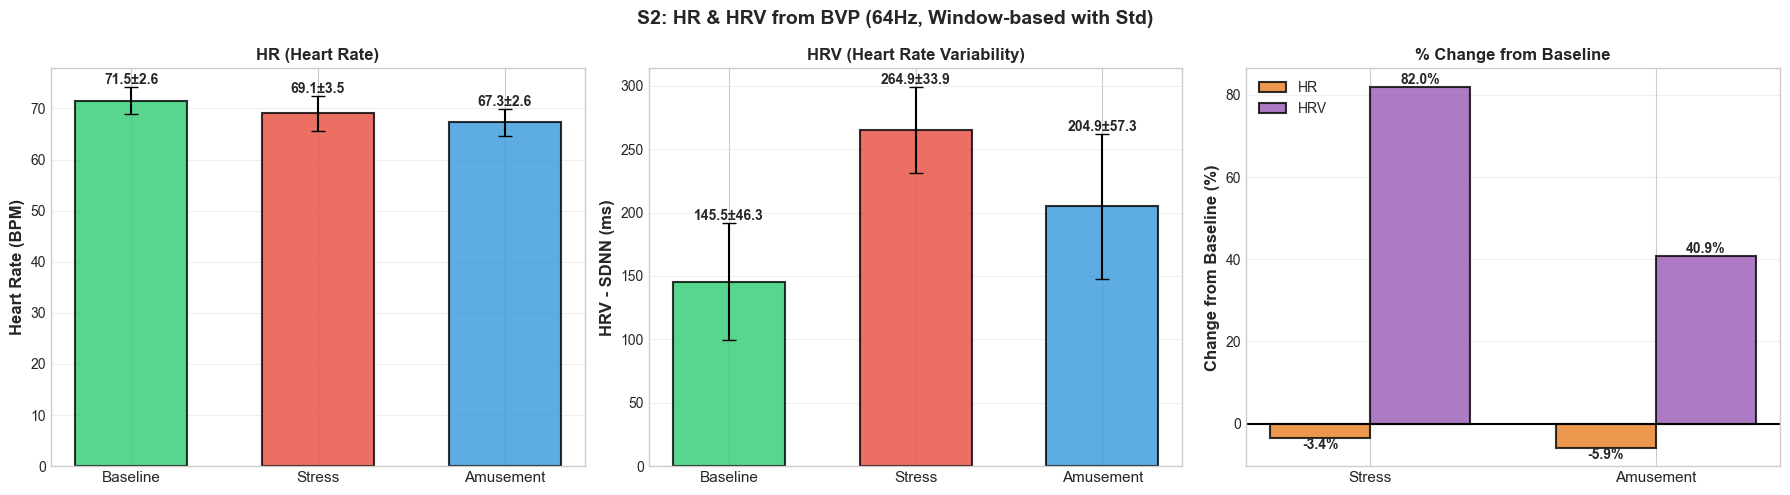


✅ HR/HRV는 BVP 원시 신호보다 훨씬 안정적이고 상태 간 차이가 명확합니다!
   윈도우 기반 분석으로 평균과 표준편차를 모두 확인할 수 있습니다.



In [28]:
# BVP에서 HR (Heart Rate)와 HRV (Heart Rate Variability) 추출 (윈도우 기반)
from scipy.signal import find_peaks

print("=" * 80)
print("HR & HRV Extraction from BVP Signal (64Hz) - Window-based Analysis")
print("=" * 80)

# S2 데이터 로드
pkl_path = WESAD_ROOT / "S2" / "S2.pkl"
with open(pkl_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

# 원본 BVP 신호 (64Hz)
bvp_64hz = data["signal"]["wrist"]["BVP"].reshape(-1)
labels_700hz = data["label"].reshape(-1)

# 레이블을 64Hz로 다운샘플링 (700Hz -> 64Hz)
label_downsample_factor = 700 // 64  # 약 10.9, 11로 근사
labels_64hz = labels_700hz[::11]

# 길이 맞추기
min_len = min(len(bvp_64hz), len(labels_64hz))
bvp_64hz = bvp_64hz[:min_len]
labels_64hz = labels_64hz[:min_len]

print(f"BVP signal length: {len(bvp_64hz)} samples ({len(bvp_64hz)/64:.1f} seconds)")
print(f"Sampling rate: 64 Hz")


def extract_hr_hrv_from_bvp_window(bvp_signal, fs=64):
    """
    BVP 신호에서 HR과 HRV를 추출 (윈도우 한 개에서)
    """
    if len(bvp_signal) < fs * 5:  # 최소 5초 필요
        return None, None
    
    # 피크 검출 (심박 피크)
    peaks, properties = find_peaks(
        bvp_signal, 
        distance=int(fs * 0.5),  # 최소 0.5초 간격
        prominence=np.std(bvp_signal) * 0.2  # 표준편차의 20%
    )
    
    if len(peaks) < 3:
        return None, None
    
    # IBI (Inter-Beat Interval) 계산 (초 단위)
    ibi = np.diff(peaks) / fs
    
    # 비정상적인 IBI 필터링 (0.4초~2초, 즉 30~150 BPM)
    valid_mask = (ibi > 0.4) & (ibi < 2.0)
    ibi_filtered = ibi[valid_mask]
    
    if len(ibi_filtered) < 2:
        return None, None
    
    # HR (Heart Rate, BPM) = 60 / mean(IBI)
    hr = 60.0 / np.mean(ibi_filtered)
    
    # HRV (SDNN) = std(IBI) * 1000 (ms 단위)
    hrv_sdnn = np.std(ibi_filtered) * 1000
    
    return hr, hrv_sdnn


def extract_hr_hrv_with_stats(bvp_signal, fs=64, window_sec=30, overlap=0.5):
    """
    윈도우 기반으로 여러 HR/HRV 값을 계산하여 평균과 표준편차 반환
    
    Parameters:
    - window_sec: 윈도우 크기 (초)
    - overlap: 윈도우 오버랩 비율 (0~1)
    """
    window_samples = int(window_sec * fs)
    step_samples = int(window_samples * (1 - overlap))
    
    hr_list = []
    hrv_list = []
    
    # 슬라이딩 윈도우로 HR/HRV 계산
    for start in range(0, len(bvp_signal) - window_samples + 1, step_samples):
        end = start + window_samples
        window_bvp = bvp_signal[start:end]
        
        hr, hrv = extract_hr_hrv_from_bvp_window(window_bvp, fs)
        
        if hr is not None and hrv is not None:
            hr_list.append(hr)
            hrv_list.append(hrv)
    
    if len(hr_list) == 0:
        return None, None, None, None
    
    return np.mean(hr_list), np.std(hr_list), np.mean(hrv_list), np.std(hrv_list)


# 각 상태별로 HR과 HRV 계산 (윈도우 기반)
states = [1, 2, 3]
state_names = ["Baseline", "Stress", "Amusement"]
colors = ["#2ecc71", "#e74c3c", "#3498db"]

hr_hrv_results = {}

for state, state_name in zip(states, state_names):
    # 해당 상태의 BVP 신호만 추출
    mask = labels_64hz == state
    bvp_state = bvp_64hz[mask]
    
    print(f"\n{state_name}:")
    print(f"  Duration: {len(bvp_state)/64:.1f} seconds")
    print(f"  Samples: {len(bvp_state)}")
    
    if len(bvp_state) < 64 * 30:  # 최소 30초 필요 (윈도우 크기)
        print(f"  ❌ Insufficient data (need at least 30 seconds)")
        continue
    
    # HR/HRV 추출 (윈도우 기반)
    hr_mean, hr_std, hrv_mean, hrv_std = extract_hr_hrv_with_stats(
        bvp_state, fs=64, window_sec=30, overlap=0.5
    )
    
    if hr_mean is not None:
        hr_hrv_results[state_name] = {
            "HR_mean": hr_mean,
            "HR_std": hr_std,
            "HRV_mean": hrv_mean,
            "HRV_std": hrv_std,
        }
        print(f"  ✅ HR:  Mean={hr_mean:.1f} BPM, Std={hr_std:.1f} BPM")
        print(f"  ✅ HRV: Mean={hrv_mean:.1f} ms, Std={hrv_std:.1f} ms")
    else:
        print(f"  ❌ Failed to extract HR/HRV")

# Change from Baseline 계산
if "Baseline" in hr_hrv_results and len(hr_hrv_results) >= 2:
    baseline_hr = hr_hrv_results["Baseline"]["HR_mean"]
    baseline_hrv = hr_hrv_results["Baseline"]["HRV_mean"]
    
    print("\n" + "=" * 80)
    print("CHANGE FROM BASELINE (%)")
    print("=" * 80)
    
    for state_name in ["Stress", "Amusement"]:
        if state_name in hr_hrv_results:
            hr_change = ((hr_hrv_results[state_name]["HR_mean"] - baseline_hr) / baseline_hr * 100)
            hrv_change = ((hr_hrv_results[state_name]["HRV_mean"] - baseline_hrv) / baseline_hrv * 100)
            
            print(f"\n{state_name}:")
            print(f"  HR:  {hr_change:+.2f}% ({hr_hrv_results[state_name]['HR_mean']:.1f}±{hr_hrv_results[state_name]['HR_std']:.1f} BPM)")
            print(f"  HRV: {hrv_change:+.2f}% ({hr_hrv_results[state_name]['HRV_mean']:.1f}±{hr_hrv_results[state_name]['HRV_std']:.1f} ms)")

# 시각화
if len(hr_hrv_results) >= 2:
    print("\n" + "=" * 80)
    print("📊 Plotting HR & HRV Comparison with Error Bars...")
    print("=" * 80)
    
    # 데이터 준비
    available_states = []
    hr_means = []
    hr_stds = []
    hrv_means = []
    hrv_stds = []
    state_colors = []
    
    for state_name, color in zip(state_names, colors):
        if state_name in hr_hrv_results:
            available_states.append(state_name)
            hr_means.append(hr_hrv_results[state_name]["HR_mean"])
            hr_stds.append(hr_hrv_results[state_name]["HR_std"])
            hrv_means.append(hr_hrv_results[state_name]["HRV_mean"])
            hrv_stds.append(hr_hrv_results[state_name]["HRV_std"])
            state_colors.append(color)
    
    # 그래프 생성
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("S2: HR & HRV from BVP (64Hz, Window-based with Std)", fontsize=14, fontweight="bold")
    
    x = np.arange(len(available_states))
    width = 0.6
    
    # Plot 1: HR (Heart Rate) with error bars
    ax = axes[0]
    bars = ax.bar(x, hr_means, width=width, yerr=hr_stds, color=state_colors, 
                  alpha=0.8, edgecolor='black', linewidth=1.5, capsize=5, 
                  error_kw={'linewidth': 1.5})
    ax.set_ylabel("Heart Rate (BPM)", fontsize=12, fontweight='bold')
    ax.set_title("HR (Heart Rate)", fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(available_states, fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar, val, std in zip(bars, hr_means, hr_stds):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + std,
                f'{val:.1f}±{std:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Plot 2: HRV (Heart Rate Variability - SDNN) with error bars
    ax = axes[1]
    bars = ax.bar(x, hrv_means, width=width, yerr=hrv_stds, color=state_colors, 
                  alpha=0.8, edgecolor='black', linewidth=1.5, capsize=5,
                  error_kw={'linewidth': 1.5})
    ax.set_ylabel("HRV - SDNN (ms)", fontsize=12, fontweight='bold')
    ax.set_title("HRV (Heart Rate Variability)", fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(available_states, fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar, val, std in zip(bars, hrv_means, hrv_stds):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + std,
                f'{val:.1f}±{std:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Plot 3: Percentage Change from Baseline
    ax = axes[2]
    if "Baseline" in available_states:
        baseline_idx = available_states.index("Baseline")
        baseline_hr = hr_means[baseline_idx]
        baseline_hrv = hrv_means[baseline_idx]
        
        change_states = []
        hr_changes = []
        hrv_changes = []
        
        for i, state_name in enumerate(available_states):
            if state_name != "Baseline":
                change_states.append(state_name)
                hr_change = ((hr_means[i] - baseline_hr) / baseline_hr * 100)
                hrv_change = ((hrv_means[i] - baseline_hrv) / baseline_hrv * 100)
                hr_changes.append(hr_change)
                hrv_changes.append(hrv_change)
        
        if len(change_states) > 0:
            x_pos = np.arange(len(change_states))
            width_change = 0.35
            
            bars1 = ax.bar(x_pos - width_change/2, hr_changes, width_change, 
                          label="HR", color="#e67e22", alpha=0.8, edgecolor='black', linewidth=1.5)
            bars2 = ax.bar(x_pos + width_change/2, hrv_changes, width_change, 
                          label="HRV", color="#9b59b6", alpha=0.8, edgecolor='black', linewidth=1.5)
            
            ax.set_ylabel("Change from Baseline (%)", fontsize=12, fontweight='bold')
            ax.set_title("% Change from Baseline", fontsize=12, fontweight='bold')
            ax.set_xticks(x_pos)
            ax.set_xticklabels(change_states, fontsize=11)
            ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
            ax.grid(True, alpha=0.3, axis='y')
            ax.legend(fontsize=10, loc='upper left')
            
            for bars in [bars1, bars2]:
                for bar in bars:
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                            f'{height:.1f}%', ha='center', 
                            va='bottom' if height >= 0 else 'top', 
                            fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ HR/HRV는 BVP 원시 신호보다 훨씬 안정적이고 상태 간 차이가 명확합니다!")
    print("   윈도우 기반 분석으로 평균과 표준편차를 모두 확인할 수 있습니다.")
else:
    print("\n❌ Not enough data to create plots")

print("\n" + "=" * 80)

In [ ]:
# S2~S17까지 모든 피험자 분석
print("=" * 80)
print("ANALYZING ALL SUBJECTS (S2 ~ S17)")
print("=" * 80)

# 분석할 피험자 리스트 (모든 피험자)
subjects_to_analyze = TARGET_SUBJECTS
print(f"\nSubjects to analyze: {subjects_to_analyze}")
print(f"Total subjects: {len(subjects_to_analyze)}")

# 결과 저장용 딕셔너리
all_subjects_results = {}

# 각 피험자별로 분석
for subject_id in subjects_to_analyze:
    print(f"\n{'='*80}")
    print(f"Processing {subject_id}...")
    print(f"{'='*80}")
    
    pkl_path = WESAD_ROOT / subject_id / f"{subject_id}.pkl"
    if not pkl_path.exists():
        print(f"  ❌ Missing file: {pkl_path}")
        continue
    
    try:
        # 데이터 로드
        with open(pkl_path, "rb") as f:
            data = pickle.load(f, encoding="latin1")
        
        wrist = data["signal"]["wrist"]
        chest = data["signal"]["chest"]
        labels = data["label"].reshape(-1)
        
        # 다운샘플링
        bvp_ds, acc_ds, eda_ds, temp_ds = downsample_wrist(wrist)
        acc_chest_ds, ecg_ds, emg_ds, temp_chest_ds = downsample_chest(chest)
        labels_1hz = downsample_labels_1hz(labels)
        
        # 길이 맞추기
        min_len = len(labels_1hz)
        bvp_ds = bvp_ds[:min_len]
        acc_ds = acc_ds[:min_len]
        eda_ds = eda_ds[:min_len]
        temp_ds = temp_ds[:min_len]
        emg_ds = emg_ds[:min_len]
        
        # 원본 BVP 신호 (HR/HRV 추출용)
        bvp_original = wrist["BVP"].reshape(-1)
        labels_700hz = labels
        label_downsample_factor = 700 // 64
        labels_64hz = labels_700hz[::11]
        bvp_fs = 64
        
        min_len_bvp = min(len(bvp_original), len(labels_64hz))
        bvp_original = bvp_original[:min_len_bvp]
        labels_64hz = labels_64hz[:min_len_bvp]
        
        # 상태별 분석
        results = {}
        states = [1, 2, 3]
        state_names = ["Baseline", "Stress", "Amusement"]
        
        for state, state_name in zip(states, state_names):
            # 1Hz 센서 데이터
            mask = labels_1hz == state
            
            if np.sum(mask) > 0:
                acc_mag = np.sqrt(np.sum(acc_ds[mask]**2, axis=1))
                results[state_name] = {
                    "ACC_mag_mean": np.mean(acc_mag),
                    "ACC_mag_std": np.std(acc_mag),
                    "EDA_mean": np.mean(eda_ds[mask]),
                    "EDA_std": np.std(eda_ds[mask]),
                    "TEMP_mean": np.mean(temp_ds[mask]),
                    "TEMP_std": np.std(temp_ds[mask]),
                    "EMG_mean": np.mean(emg_ds[mask]),
                    "EMG_std": np.std(emg_ds[mask]),
                }
            
            # HR/HRV 추출 (64Hz BVP)
            mask_64hz = labels_64hz == state
            bvp_state = bvp_original[mask_64hz]
            
            if len(bvp_state) >= bvp_fs * 30:  # 최소 30초 필요
                hr_mean, hr_std, hrv_mean, hrv_std = extract_hr_hrv_with_stats(
                    bvp_state, fs=bvp_fs, window_sec=30, overlap=0.5
                )
                
                if hr_mean is not None and state_name in results:
                    results[state_name]["HR_mean"] = hr_mean
                    results[state_name]["HR_std"] = hr_std
                    results[state_name]["HRV_mean"] = hrv_mean
                    results[state_name]["HRV_std"] = hrv_std
        
        # 결과 저장
        all_subjects_results[subject_id] = results
        
        # 추출된 지표 출력
        print(f"  ✅ Successfully processed {subject_id}")
        for state_name in state_names:
            if state_name in results:
                metrics = results[state_name]
                available = [k.replace('_mean', '').replace('_std', '') for k in metrics.keys() if '_mean' in k]
                available = list(set(available))
                print(f"     {state_name}: {', '.join(available)}")
        
    except Exception as e:
        print(f"  ❌ Error processing {subject_id}: {e}")
        continue

print(f"\n{'='*80}")
print(f"✅ Processing complete!")
print(f"Successfully analyzed: {len(all_subjects_results)} subjects")
print(f"{'='*80}")


ANALYZING ALL SUBJECTS (S3 ~ S17)

Subjects to analyze: ['S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
Total subjects: 14

Processing S3...
  ✅ Successfully processed S3
     Baseline: EDA, TEMP, ACC_mag, HR, HRV, EMG
     Stress: EDA, TEMP, ACC_mag, HR, HRV, EMG
     Amusement: EDA, TEMP, ACC_mag, HR, HRV, EMG

Processing S4...
  ✅ Successfully processed S4
     Baseline: EDA, TEMP, ACC_mag, HR, HRV, EMG
     Stress: EDA, TEMP, ACC_mag, HR, HRV, EMG
     Amusement: EDA, TEMP, ACC_mag, HR, HRV, EMG

Processing S5...
  ✅ Successfully processed S5
     Baseline: EDA, TEMP, ACC_mag, HR, HRV, EMG
     Stress: EDA, TEMP, ACC_mag, HR, HRV, EMG
     Amusement: EDA, TEMP, ACC_mag, HR, HRV, EMG

Processing S6...
  ✅ Successfully processed S6
     Baseline: EDA, TEMP, ACC_mag, HR, HRV, EMG
     Stress: EDA, TEMP, ACC_mag, HR, HRV, EMG
     Amusement: EDA, TEMP, ACC_mag, HR, HRV, EMG

Processing S7...
  ✅ Successfully processed S7
     Baseline: EDA, T

In [33]:
# 전체 피험자 데이터 집계 및 시각화
print("=" * 80)
print("AGGREGATING ALL SUBJECTS DATA")
print("=" * 80)

# 센서 목록
sensors = ["ACC", "EDA", "TEMP", "EMG", "HR", "HRV"]
states = ["Baseline", "Stress", "Amusement"]
colors = ["#2ecc71", "#e74c3c", "#3498db"]

# 각 상태별, 센서별 데이터 수집
aggregated_data = {state: {sensor: [] for sensor in sensors} for state in states}

for subject_id, results in all_subjects_results.items():
    for state_name in states:
        if state_name in results:
            metrics = results[state_name]
            
            # 각 센서의 평균값 수집
            if "ACC_mag_mean" in metrics:
                aggregated_data[state_name]["ACC"].append(metrics["ACC_mag_mean"])
            if "EDA_mean" in metrics:
                aggregated_data[state_name]["EDA"].append(metrics["EDA_mean"])
            if "TEMP_mean" in metrics:
                aggregated_data[state_name]["TEMP"].append(metrics["TEMP_mean"])
            if "EMG_mean" in metrics:
                aggregated_data[state_name]["EMG"].append(metrics["EMG_mean"])
            if "HR_mean" in metrics:
                aggregated_data[state_name]["HR"].append(metrics["HR_mean"])
            if "HRV_mean" in metrics:
                aggregated_data[state_name]["HRV"].append(metrics["HRV_mean"])

# 각 상태별, 센서별 평균과 표준편차 계산
summary_stats = {state: {} for state in states}

print("\n" + "=" * 80)
print("SUMMARY STATISTICS (Mean ± Std across all subjects)")
print("=" * 80)

for state_name in states:
    print(f"\n{state_name.upper()}:")
    for sensor in sensors:
        if len(aggregated_data[state_name][sensor]) > 0:
            data = np.array(aggregated_data[state_name][sensor])
            mean_val = np.mean(data)
            std_val = np.std(data)
            summary_stats[state_name][sensor] = {
                "mean": mean_val,
                "std": std_val,
                "n_subjects": len(data)
            }
            
            unit = ""
            if sensor == "HR":
                unit = " BPM"
            elif sensor == "HRV":
                unit = " ms"
            elif sensor == "EDA":
                unit = " uS"
            elif sensor == "TEMP":
                unit = " °C"
            
            print(f"  {sensor:6s}: {mean_val:8.3f} ± {std_val:6.3f}{unit:5s} (n={len(data)})")
        else:
            print(f"  {sensor:6s}: No data")

print("\n" + "=" * 80)


AGGREGATING ALL SUBJECTS DATA

SUMMARY STATISTICS (Mean ± Std across all subjects)

BASELINE:
  ACC   :   63.616 ±  0.733      (n=14)
  EDA   :    1.399 ±  1.631 uS   (n=14)
  TEMP  :   33.175 ±  1.445 °C   (n=14)
  EMG   :   -0.003 ±  0.001      (n=14)
  HR    :   69.713 ±  7.131 BPM  (n=14)
  HRV   :  181.311 ± 25.862 ms   (n=14)

STRESS:
  ACC   :   63.825 ±  1.117      (n=14)
  EDA   :    3.623 ±  3.672 uS   (n=14)
  TEMP  :   32.594 ±  0.971 °C   (n=14)
  EMG   :   -0.003 ±  0.001      (n=14)
  HR    :   72.311 ±  3.759 BPM  (n=14)
  HRV   :  250.652 ± 27.631 ms   (n=14)

AMUSEMENT:
  ACC   :   63.369 ±  0.676      (n=14)
  EDA   :    1.438 ±  1.676 uS   (n=14)
  TEMP  :   32.469 ±  1.496 °C   (n=14)
  EMG   :   -0.003 ±  0.001      (n=14)
  HR    :   70.996 ±  6.481 BPM  (n=14)
  HRV   :  177.577 ± 44.666 ms   (n=14)



📊 PLOTTING ALL SUBJECTS RESULTS


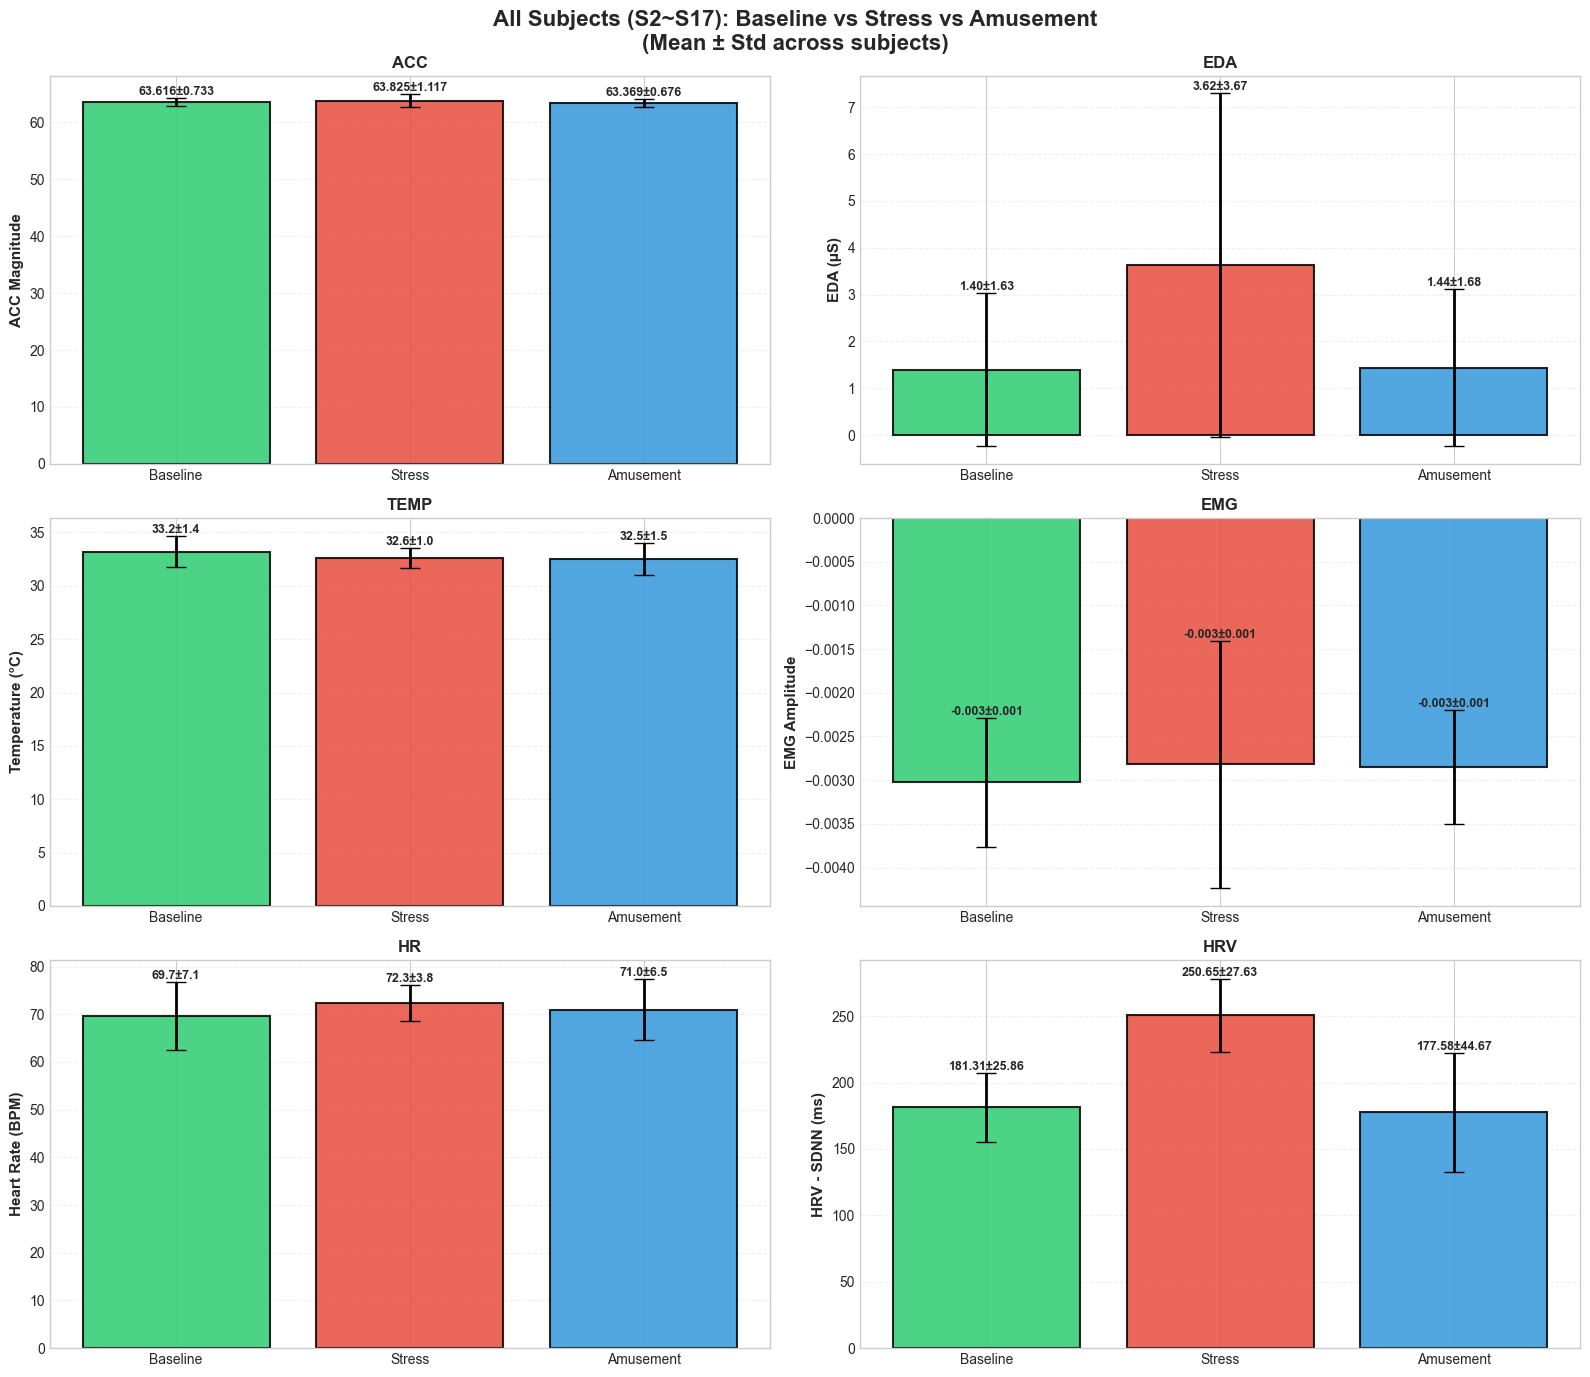


✅ All subjects visualization complete!


In [30]:
# 전체 피험자 시각화 (3x2 subplot)
print("=" * 80)
print("📊 PLOTTING ALL SUBJECTS RESULTS")
print("=" * 80)

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle("All Subjects (S2~S17): Baseline vs Stress vs Amusement\n(Mean ± Std across subjects)", 
             fontsize=16, fontweight="bold")

axes_flat = axes.flatten()

for idx, sensor in enumerate(sensors):
    ax = axes_flat[idx]
    
    # 데이터 준비
    means = []
    stds = []
    state_labels = []
    bar_colors = []
    
    for state_name, color in zip(states, colors):
        if sensor in summary_stats[state_name] and summary_stats[state_name][sensor]["n_subjects"] > 0:
            means.append(summary_stats[state_name][sensor]["mean"])
            stds.append(summary_stats[state_name][sensor]["std"])
            state_labels.append(state_name)
            bar_colors.append(color)
    
    if len(means) > 0:
        x = np.arange(len(state_labels))
        bars = ax.bar(x, means, yerr=stds, color=bar_colors, alpha=0.85, 
                      edgecolor='black', linewidth=1.5, capsize=7, 
                      error_kw={'linewidth': 2, 'elinewidth': 2})
        
        # 레이블 설정
        unit = ""
        ylabel = sensor
        if sensor == "HR":
            ylabel = "Heart Rate (BPM)"
        elif sensor == "HRV":
            ylabel = "HRV - SDNN (ms)"
        elif sensor == "ACC":
            ylabel = "ACC Magnitude"
        elif sensor == "EDA":
            ylabel = "EDA (µS)"
        elif sensor == "TEMP":
            ylabel = "Temperature (°C)"
        elif sensor == "EMG":
            ylabel = "EMG Amplitude"
        
        ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
        ax.set_title(f"{sensor}", fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(state_labels, fontsize=10)
        ax.grid(True, alpha=0.3, axis='y', linestyle='--')
        
        # 값 표시
        for bar, mean, std in zip(bars, means, stds):
            height = bar.get_height()
            if sensor in ["HR", "TEMP"]:
                label_text = f'{mean:.1f}±{std:.1f}'
            elif sensor in ["ACC", "EMG"]:
                label_text = f'{mean:.3f}±{std:.3f}'
            else:
                label_text = f'{mean:.2f}±{std:.2f}'
            
            ax.text(bar.get_x() + bar.get_width()/2., height + std,
                    label_text, ha='center', va='bottom', 
                    fontsize=9, fontweight='bold')
    else:
        ax.text(0.5, 0.5, f"No {sensor} data available", 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_xticks([])

plt.tight_layout()
plt.show()

print("\n✅ All subjects visualization complete!")
print("=" * 80)


CALCULATING CHANGES FROM BASELINE

STRESS vs Baseline:
  ACC   :   +0.33%
  EDA   : +159.05%
  TEMP  :   -1.75%
  EMG   :   -6.86%
  HR    :   +3.73%
  HRV   :  +38.24%

AMUSEMENT vs Baseline:
  ACC   :   -0.39%
  EDA   :   +2.77%
  TEMP  :   -2.13%
  EMG   :   -5.80%
  HR    :   +1.84%
  HRV   :   -2.06%


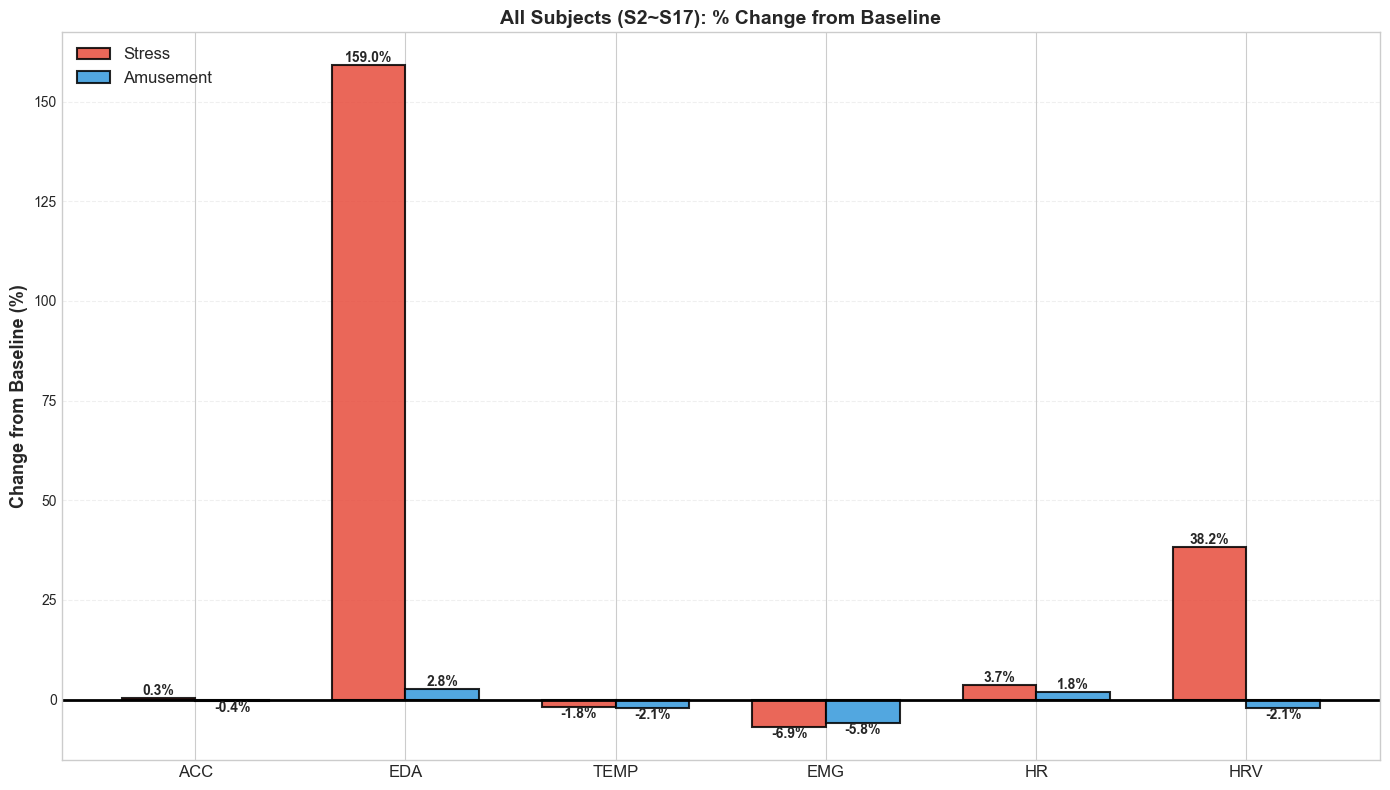


✅ Change from baseline visualization complete!


In [34]:
# Baseline 대비 변화율 계산 및 시각화
print("=" * 80)
print("CALCULATING CHANGES FROM BASELINE")
print("=" * 80)

# Baseline 대비 변화율 계산
change_from_baseline = {}

if "Baseline" in summary_stats:
    for state_name in ["Stress", "Amusement"]:
        if state_name in summary_stats:
            change_from_baseline[state_name] = {}
            
            print(f"\n{state_name.upper()} vs Baseline:")
            for sensor in sensors:
                if sensor in summary_stats["Baseline"] and sensor in summary_stats[state_name]:
                    baseline_mean = summary_stats["Baseline"][sensor]["mean"]
                    state_mean = summary_stats[state_name][sensor]["mean"]
                    
                    if baseline_mean != 0:
                        change_pct = ((state_mean - baseline_mean) / baseline_mean) * 100
                        change_from_baseline[state_name][sensor] = change_pct
                        print(f"  {sensor:6s}: {change_pct:+7.2f}%")

# 변화율 시각화
if len(change_from_baseline) > 0:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # 데이터 준비
    x_pos = np.arange(len(sensors))
    width = 0.35
    
    stress_changes = [change_from_baseline.get("Stress", {}).get(s, 0) for s in sensors]
    amusement_changes = [change_from_baseline.get("Amusement", {}).get(s, 0) for s in sensors]
    
    # 막대 그래프
    bars1 = ax.bar(x_pos - width/2, stress_changes, width, 
                   label="Stress", color="#e74c3c", alpha=0.85, 
                   edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x_pos + width/2, amusement_changes, width, 
                   label="Amusement", color="#3498db", alpha=0.85, 
                   edgecolor='black', linewidth=1.5)
    
    # 그래프 설정
    ax.set_ylabel("Change from Baseline (%)", fontsize=13, fontweight='bold')
    ax.set_title("All Subjects (S2~S17): % Change from Baseline", 
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(sensors, fontsize=12)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=2)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax.legend(fontsize=12, loc='upper left', framealpha=0.9)
    
    # 값 표시
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', 
                    va='bottom' if height >= 0 else 'top', 
                    fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Change from baseline visualization complete!")
else:
    print("\n❌ Cannot calculate changes - missing Baseline data")

print("=" * 80)


📊 SUBJECT-WISE DETAILED COMPARISON

Plotting ACC...


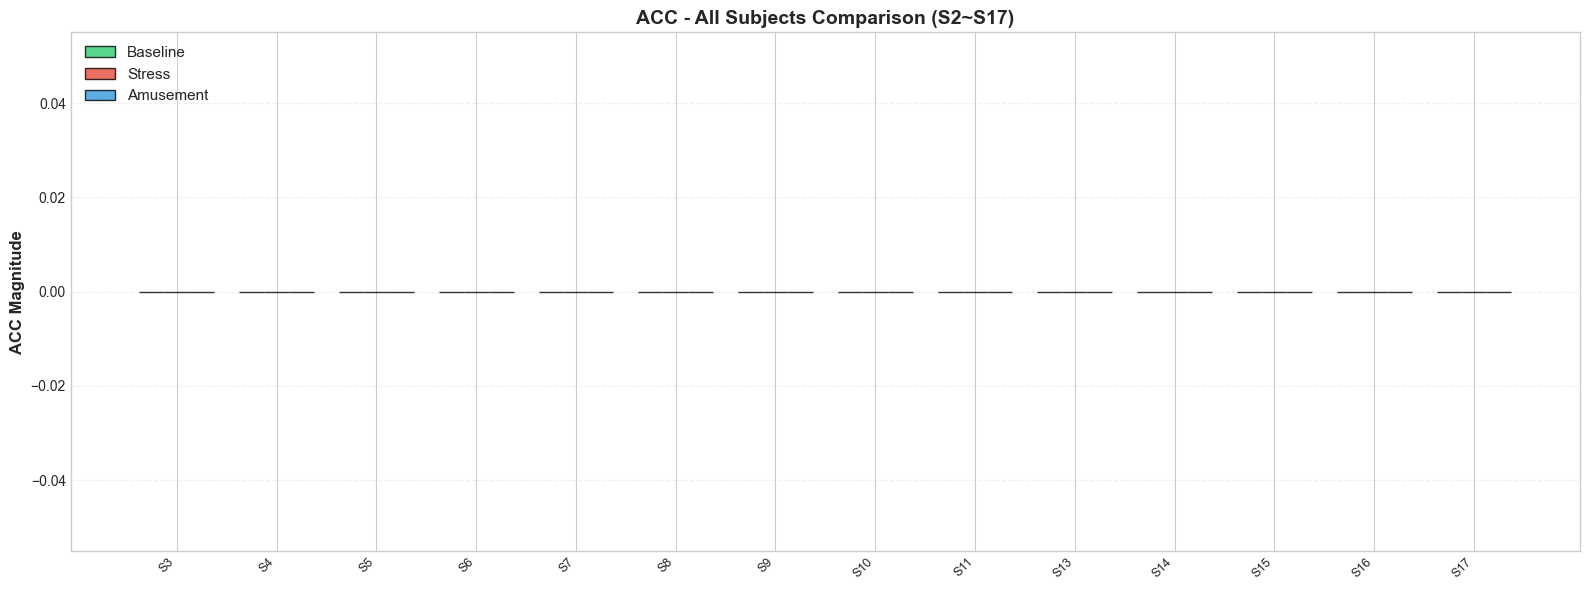


Plotting EDA...


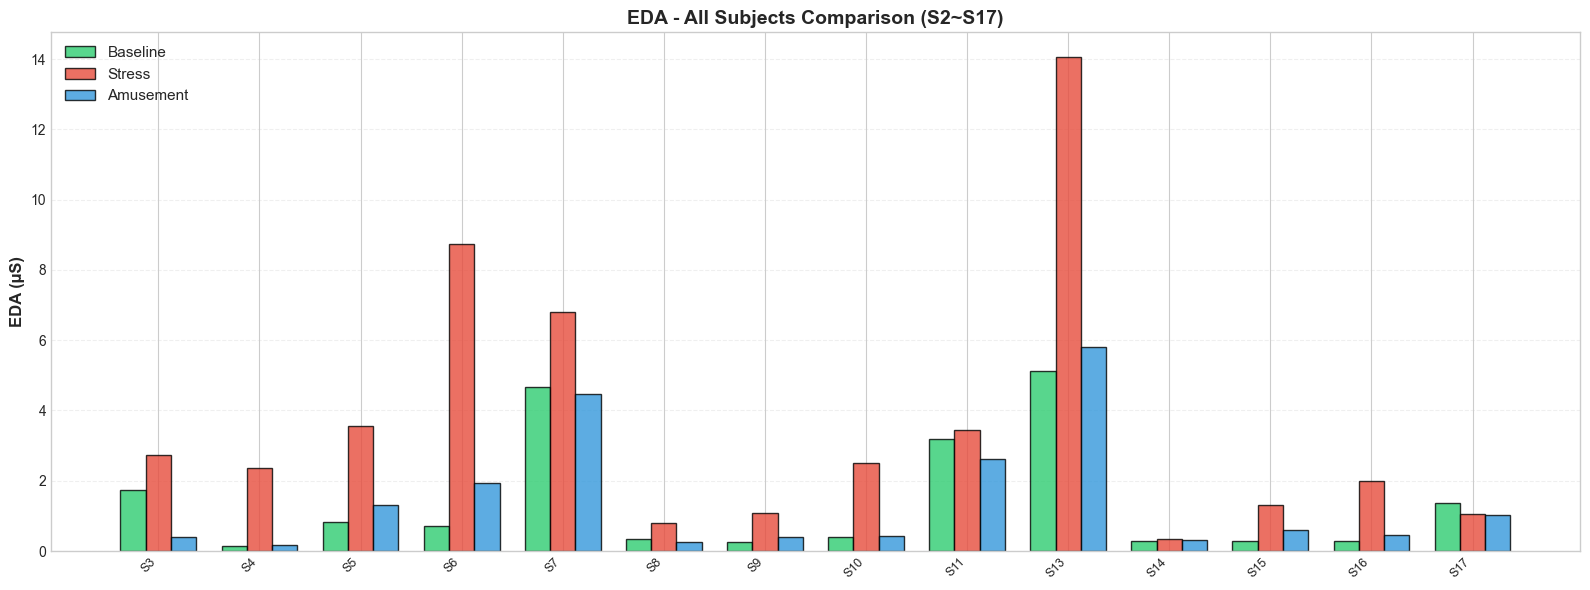


Plotting HR...


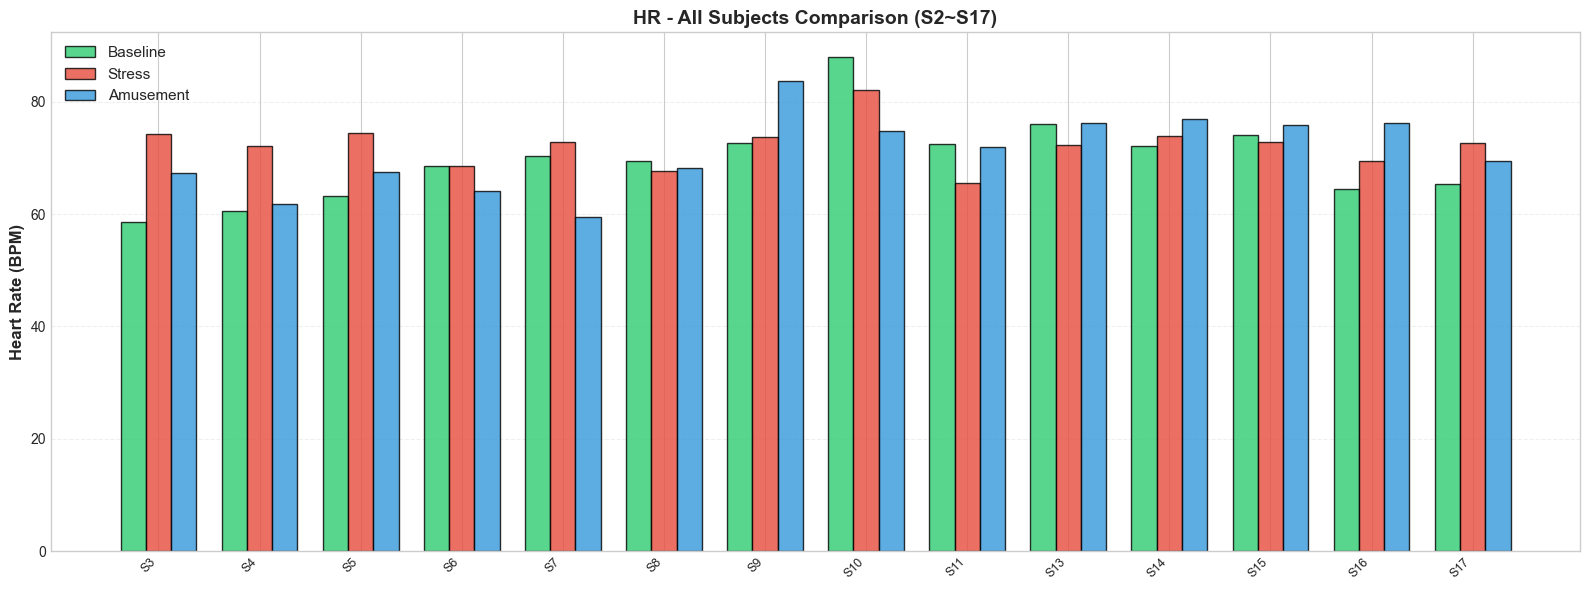


Plotting HRV...


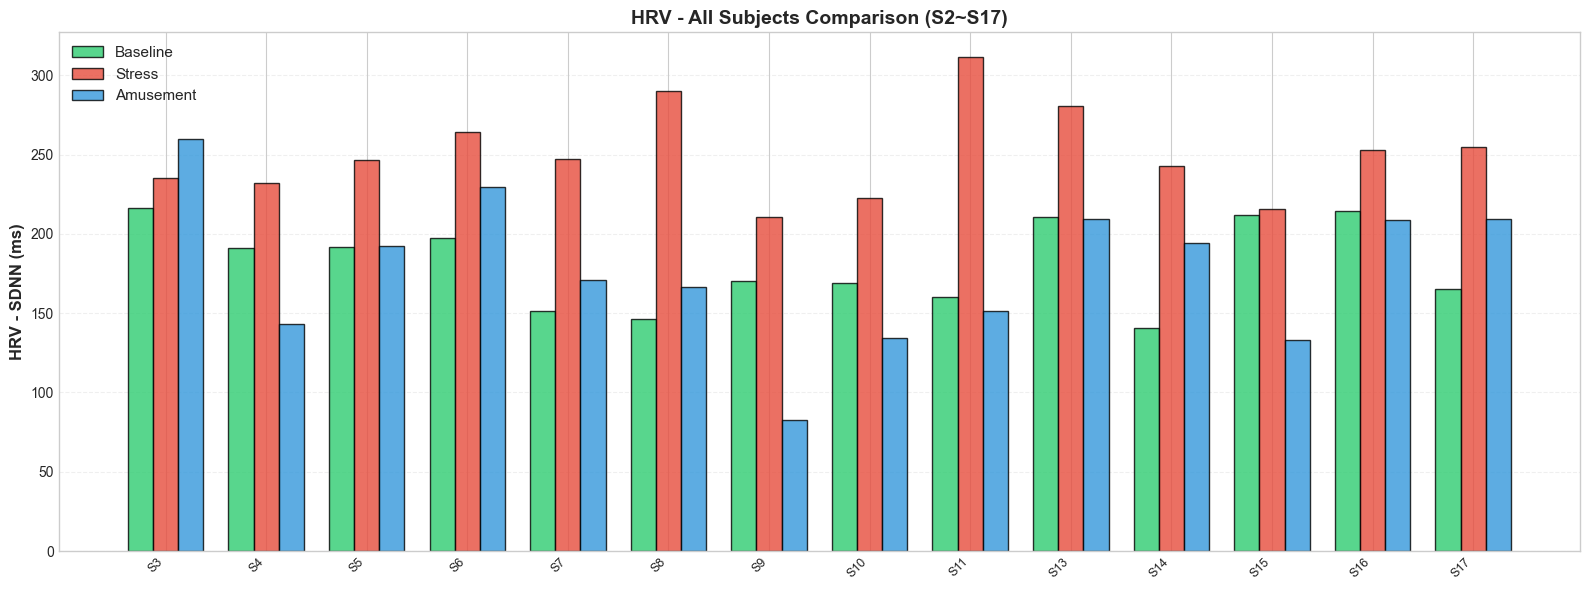


✅ Subject-wise comparison complete!


In [32]:
# 피험자별 상세 비교 (각 센서별로 모든 피험자 표시)
print("=" * 80)
print("📊 SUBJECT-WISE DETAILED COMPARISON")
print("=" * 80)

# 선택한 주요 센서들
key_sensors = ["ACC", "EDA", "HR", "HRV"]

for sensor in key_sensors:
    print(f"\nPlotting {sensor}...")
    
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # 피험자 ID 리스트 (S2, S3, ..., S17 순서로 정렬)
    subject_ids = sorted([s for s in all_subjects_results.keys()], key=lambda x: int(x[1:]))
    n_subjects = len(subject_ids)
    
    # 막대 그래프 위치 설정
    x = np.arange(n_subjects)
    width = 0.25
    
    # 각 상태별 데이터 수집
    baseline_vals = []
    stress_vals = []
    amusement_vals = []
    
    for subject_id in subject_ids:
        results = all_subjects_results[subject_id]
        
        # Baseline
        if "Baseline" in results and f"{sensor}_mean" in results["Baseline"]:
            if sensor == "ACC":
                baseline_vals.append(results["Baseline"]["ACC_mag_mean"])
            else:
                baseline_vals.append(results["Baseline"][f"{sensor}_mean"])
        else:
            baseline_vals.append(0)
        
        # Stress
        if "Stress" in results and f"{sensor}_mean" in results["Stress"]:
            if sensor == "ACC":
                stress_vals.append(results["Stress"]["ACC_mag_mean"])
            else:
                stress_vals.append(results["Stress"][f"{sensor}_mean"])
        else:
            stress_vals.append(0)
        
        # Amusement
        if "Amusement" in results and f"{sensor}_mean" in results["Amusement"]:
            if sensor == "ACC":
                amusement_vals.append(results["Amusement"]["ACC_mag_mean"])
            else:
                amusement_vals.append(results["Amusement"][f"{sensor}_mean"])
        else:
            amusement_vals.append(0)
    
    # 막대 그래프 그리기
    bars1 = ax.bar(x - width, baseline_vals, width, label='Baseline', 
                   color='#2ecc71', alpha=0.8, edgecolor='black', linewidth=1)
    bars2 = ax.bar(x, stress_vals, width, label='Stress', 
                   color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1)
    bars3 = ax.bar(x + width, amusement_vals, width, label='Amusement', 
                   color='#3498db', alpha=0.8, edgecolor='black', linewidth=1)
    
    # 그래프 설정
    ylabel_map = {
        "ACC": "ACC Magnitude",
        "EDA": "EDA (µS)",
        "HR": "Heart Rate (BPM)",
        "HRV": "HRV - SDNN (ms)"
    }
    
    ax.set_ylabel(ylabel_map.get(sensor, sensor), fontsize=12, fontweight='bold')
    ax.set_title(f"{sensor} - All Subjects Comparison (S2~S17)", 
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(subject_ids, fontsize=9, rotation=45, ha='right')
    ax.legend(fontsize=11, loc='upper left')
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    plt.tight_layout()
    plt.show()

print("\n✅ Subject-wise comparison complete!")
print("=" * 80)
